In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
df_maestro = pd.read_csv('C:\\Users\\darch\\Documents\\python\\descriptiva\\descriptiva-real-estate\\data\\raw\\dataframe_maestro.tsv', sep='\t')

In [49]:
df = df_maestro.copy()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66180 entries, 0 to 66179
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Fecha_Scraping     66180 non-null  object 
 1   Posting_ID         66180 non-null  int64  
 2   Sito               66180 non-null  object 
 3   Operación          66180 non-null  object 
 4   Precio             66180 non-null  object 
 5   Expensas           45549 non-null  object 
 6   Calle              60722 non-null  object 
 7   Altura             60722 non-null  float64
 8   Piso               15167 non-null  object 
 9   Barrio             66180 non-null  object 
 10  Detalles           65957 non-null  object 
 11  Descripción        65868 non-null  object 
 12  Link               66180 non-null  object 
 13  Amenities          66180 non-null  int64  
 14  Losa_Central       66180 non-null  int64  
 15  Aire_Acond         66180 non-null  int64  
 16  Apto_Credito       661

In [50]:
df.describe()

,Posting_ID,Altura,Amenities,Losa_Central,Aire_Acond,Apto_Credito,Cochera,Seguridad,Luminoso,Balcon_Aterrazado
count,6.618000e+04,60722.000000,66180.000000,66180.000000,66180.000000,66180.000000,66180.000000,66180.000000,66180.000000,66180.000000
mean,3.692180e+07,2255.691726,1.272635,0.097749,0.316893,0.072983,0.288697,0.213796,0.601224,0.091674
std,2.008695e+07,1714.396910,1.714579,0.296977,0.465269,0.260110,0.453160,0.409987,0.489650,0.288568
min,1.527159e+06,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.863395e+07,950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.938779e+07,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,5.842992e+07,3100.000000,2.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000
max,5.882838e+07,54300.000000,8.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


En primer lugar, revisamos los duplicados

In [51]:
#verifico si hay duplicados
duplicados = df.duplicated().sum()
print(f"Filas duplicadas encontradas: {duplicados}")

Filas duplicadas encontradas: 3243


In [52]:
df = df.drop_duplicates(keep = 'first').reset_index(drop=True)

In [53]:
duplicados = df.duplicated().sum()
print(f"Filas duplicadas encontradas: {duplicados}")

Filas duplicadas encontradas: 0


In [54]:
df.isnull().sum()

Fecha_Scraping           0
Posting_ID               0
Sito                     0
Operación                0
Precio                   0
Expensas             19838
Calle                 5370
Altura                5370
Piso                 49314
Barrio                   0
Detalles               220
Descripción            293
Link                     0
Amenities                0
Losa_Central             0
Aire_Acond               0
Apto_Credito             0
Cochera                  0
Seguridad                0
Luminoso                 0
Balcon_Aterrazado        0
dtype: int64

Arreglamos las columnas de los precios, identificando la moneda utilizada. Asumimos que los precios que leen 'USD' son los que están en dólares, y los que no los que estan en Pesos. 

In [55]:
df['Moneda'] = df['Precio'].apply(lambda x: 'USD' if 'usd' in str(x).lower() else 'ARS')

In [56]:
df['Precio'] = (df['Precio'].astype(str).str.lower().str.replace('usd', '', regex=False).str.replace('ars', '', regex=False).str.replace('$', '', regex=False).str.replace('.', '', regex=False).str.strip())
df['Precio'] = df["Precio"].apply(lambda x: float(x) if x != 'consultar' else np.nan)

Las expensas están siempre expresadas en pesos

In [74]:
df['Expensas'] = (df['Expensas'].str.replace('$', '', regex=False).str.replace('.', '', regex=False).str.strip())
df['Expensas'] = df["Expensas"].apply(lambda x: float(x) if x != '' else np.nan)

In [59]:
resumen_moneda = df.groupby(["Moneda", "Operación"])["Precio"].agg(["mean", "median", "std", "min", "max"])
resumen_moneda 

mean    median           std      min  \
Moneda Operación                                                          
ARS    alquiler           8.282753e+05  700000.0  9.965850e+05      1.0   
       alquiler_temporal  7.122810e+05  750000.0  3.849273e+05      1.0   
       venta              6.357208e+06  200000.0  2.414848e+07  50000.0   
USD    alquiler           5.346962e+03    1200.0  5.369935e+04      1.0   
       alquiler_temporal  5.744404e+03     850.0  2.247339e+05      5.0   
       venta              2.428972e+05  148000.0  3.647445e+05      1.0   

                                  max  
Moneda Operación                       
ARS    alquiler           111111111.0  
       alquiler_temporal    2800000.0  
       venta              150000000.0  
USD    alquiler             1850000.0  
       alquiler_temporal   12322222.0  
       venta               12000000.0

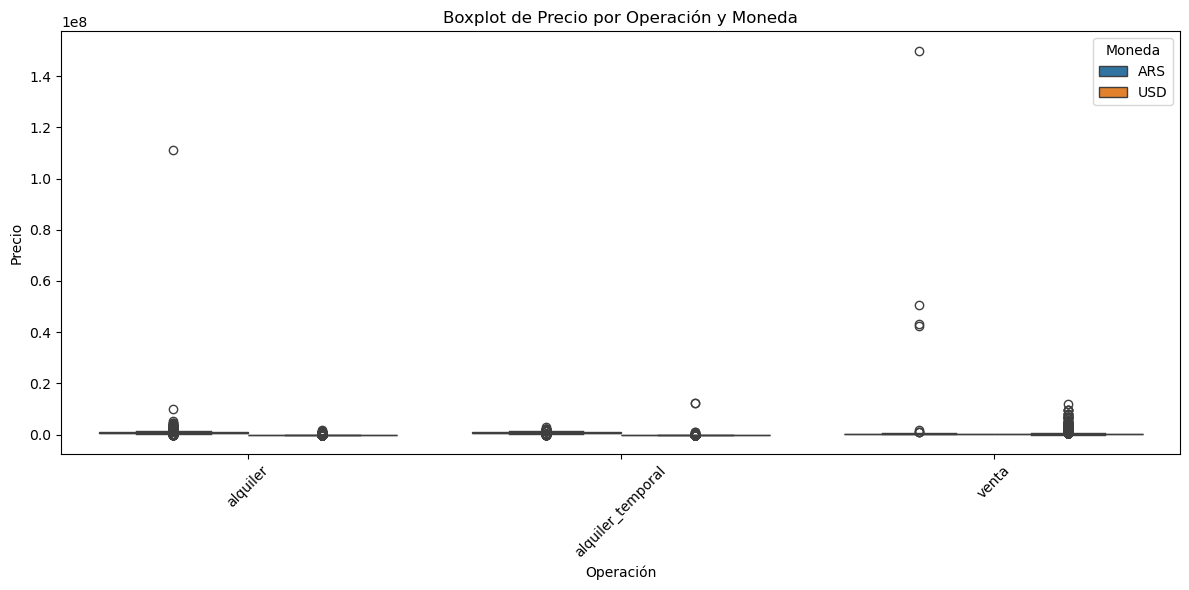

In [60]:
df_plot = df.dropna(subset=["Precio", "Moneda", "Operación"]).copy()
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_plot, x="Operación", y="Precio", hue="Moneda")
plt.title("Boxplot de Precio por Operación y Moneda")
plt.xlabel("Operación")
plt.ylabel("Precio")
plt.xticks(rotation=45)
plt.legend(title="Moneda")
plt.tight_layout()
plt.show()

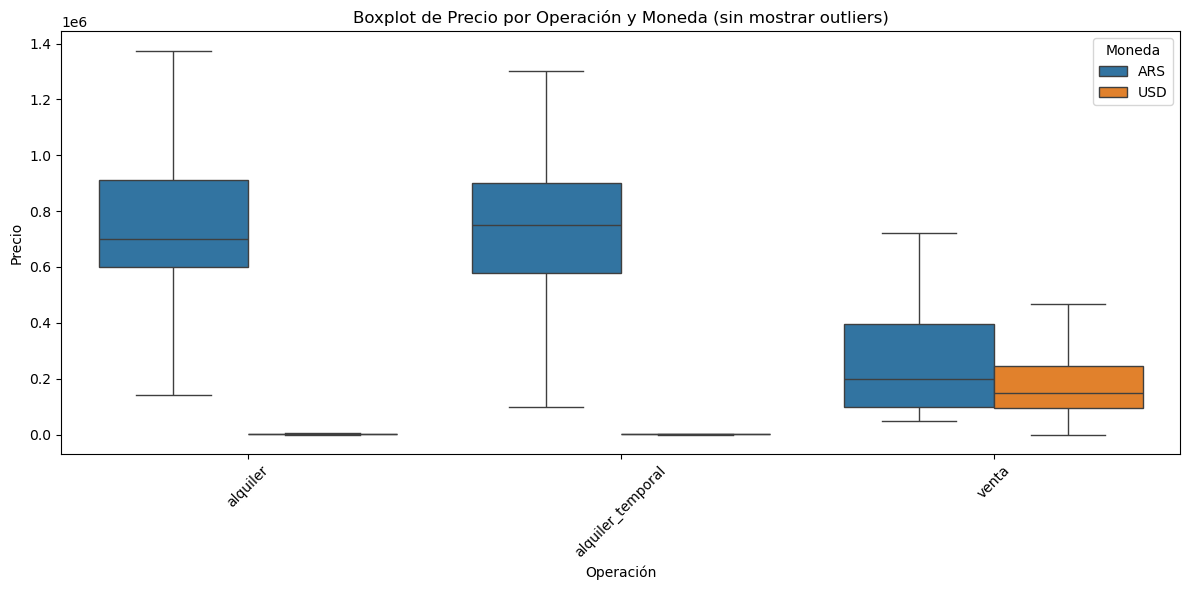

In [61]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_plot, x="Operación", y="Precio", hue="Moneda", showfliers=False)
plt.title("Boxplot de Precio por Operación y Moneda (sin mostrar outliers)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [76]:
df.columns

Index(['Fecha_Scraping', 'Posting_ID', 'Sito', 'Operación', 'Precio',
       'Expensas', 'Calle', 'Altura', 'Piso', 'Barrio', 'Detalles',
       'Descripción', 'Link', 'Amenities', 'Losa_Central', 'Aire_Acond',
       'Apto_Credito', 'Cochera', 'Seguridad', 'Luminoso', 'Balcon_Aterrazado',
       'Moneda'],
      dtype='object')